In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Indian_Climate_Dataset_2024_2025.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9


In [2]:
# Display basic information about the DataFrame to check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  7310 non-null   object 
 1   City                  7310 non-null   object 
 2   State                 7310 non-null   object 
 3   Temperature_Max (°C)  7310 non-null   float64
 4   Temperature_Min (°C)  7310 non-null   float64
 5   Temperature_Avg (°C)  7310 non-null   float64
 6   Humidity (%)          7310 non-null   float64
 7   Rainfall (mm)         7310 non-null   float64
 8   Wind_Speed (km/h)     7310 non-null   float64
 9   AQI                   7310 non-null   int64  
 10  AQI_Category          7310 non-null   object 
 11  Pressure (hPa)        7310 non-null   float64
 12  Cloud_Cover (%)       7310 non-null   float64
dtypes: float64(8), int64(1), object(4)
memory usage: 742.6+ KB


In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Calculate average values if only min/max are provided (assuming an average is needed)
# If an 'Avg' column already exists, this step might be skipped or adapted
# For Temperature, Humidity, Rainfall, and Wind Speed, we will assume an average is needed

df['Temperature_Avg (°C)'] = (df['Temperature_Max (°C)'] + df['Temperature_Min (°C)']) / 2

# Check for duplicate entries
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

# Display basic information about the DataFrame after cleaning
df.info()

Number of duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  7310 non-null   datetime64[ns]
 1   City                  7310 non-null   object        
 2   State                 7310 non-null   object        
 3   Temperature_Max (°C)  7310 non-null   float64       
 4   Temperature_Min (°C)  7310 non-null   float64       
 5   Temperature_Avg (°C)  7310 non-null   float64       
 6   Humidity (%)          7310 non-null   float64       
 7   Rainfall (mm)         7310 non-null   float64       
 8   Wind_Speed (km/h)     7310 non-null   float64       
 9   AQI                   7310 non-null   int64         
 10  AQI_Category          7310 non-null   object        
 11  Pressure (hPa)        7310 non-null   float64       
 12  Cloud_Cover (%)       7310 non-null   float64   

In [4]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Check for duplicate entries
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

# Display basic information about the DataFrame after cleaning
df.info()

Number of duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  7310 non-null   datetime64[ns]
 1   City                  7310 non-null   object        
 2   State                 7310 non-null   object        
 3   Temperature_Max (°C)  7310 non-null   float64       
 4   Temperature_Min (°C)  7310 non-null   float64       
 5   Temperature_Avg (°C)  7310 non-null   float64       
 6   Humidity (%)          7310 non-null   float64       
 7   Rainfall (mm)         7310 non-null   float64       
 8   Wind_Speed (km/h)     7310 non-null   float64       
 9   AQI                   7310 non-null   int64         
 10  AQI_Category          7310 non-null   object        
 11  Pressure (hPa)        7310 non-null   float64       
 12  Cloud_Cover (%)       7310 non-null   float64   

In [5]:
# Extract year, month, and day of the week for trend analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()

# Display the DataFrame with new time components
display(df.head())

,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%),Year,Month,Day_of_Week
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.25,77.6,0.0,3.3,259,Poor,1020.3,62.1,2024,January,Monday
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.05,84.1,0.0,9.0,130,Moderate,1008.4,46.0,2024,January,Monday
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.00,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3,2024,January,Monday
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.80,34.2,9.5,9.0,176,Moderate,993.4,70.0,2024,January,Monday
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.45,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9,2024,January,Monday


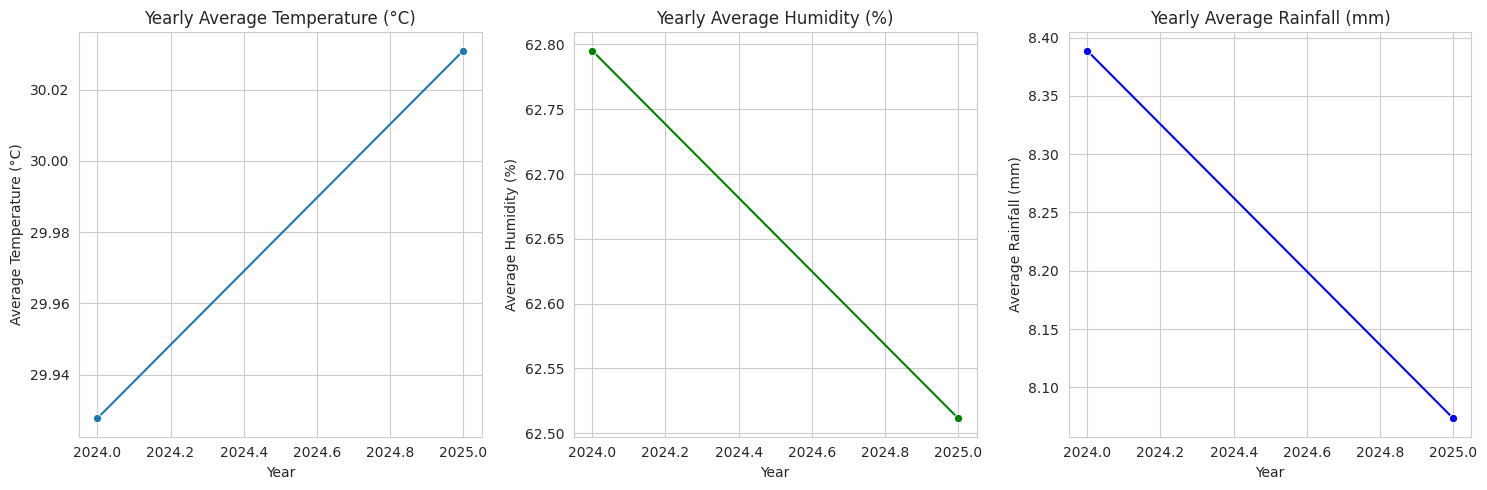

/tmp/ipykernel_2608/2344174770.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg_data = df.groupby('Month')[['Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)']].mean().reset_index()


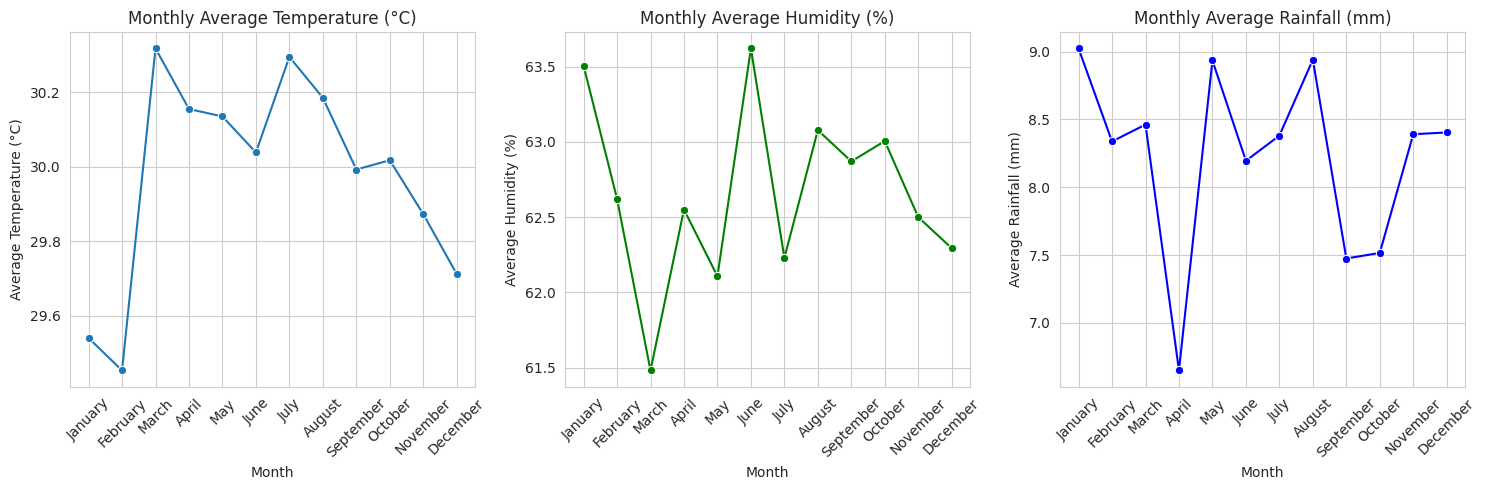

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Yearly Trends
yearly_avg_data = df.groupby('Year')[['Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)']].mean().reset_index()

plt.figure(figsize=(15, 5))

# Plot Yearly Average Temperature
plt.subplot(1, 3, 1)
sns.lineplot(x='Year', y='Temperature_Avg (°C)', data=yearly_avg_data, marker='o')
plt.title('Yearly Average Temperature (°C)')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')

# Plot Yearly Average Humidity
plt.subplot(1, 3, 2)
sns.lineplot(x='Year', y='Humidity (%)', data=yearly_avg_data, marker='o', color='green')
plt.title('Yearly Average Humidity (%)')
plt.xlabel('Year')
plt.ylabel('Average Humidity (%)')

# Plot Yearly Average Rainfall
plt.subplot(1, 3, 3)
sns.lineplot(x='Year', y='Rainfall (mm)', data=yearly_avg_data, marker='o', color='blue')
plt.title('Yearly Average Rainfall (mm)')
plt.xlabel('Year')
plt.ylabel('Average Rainfall (mm)')

plt.tight_layout()
plt.show()

# Monthly Trends
# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_avg_data = df.groupby('Month')[['Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)']].mean().reset_index()

plt.figure(figsize=(15, 5))

# Plot Monthly Average Temperature
plt.subplot(1, 3, 1)
sns.lineplot(x='Month', y='Temperature_Avg (°C)', data=monthly_avg_data, marker='o')
plt.title('Monthly Average Temperature (°C)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)

# Plot Monthly Average Humidity
plt.subplot(1, 3, 2)
sns.lineplot(x='Month', y='Humidity (%)', data=monthly_avg_data, marker='o', color='green')
plt.title('Monthly Average Humidity (%)')
plt.xlabel('Month')
plt.ylabel('Average Humidity (%)')
plt.xticks(rotation=45)

# Plot Monthly Average Rainfall
plt.subplot(1, 3, 3)
sns.lineplot(x='Month', y='Rainfall (mm)', data=monthly_avg_data, marker='o', color='blue')
plt.title('Monthly Average Rainfall (mm)')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,City,Temperature_Avg (°C),Humidity (%),Rainfall (mm),AQI,Wind_Speed (km/h),Pressure (hPa),Cloud_Cover (%)
0,Ahmedabad,30.144802,63.664432,8.457729,193.800274,13.529685,1007.533105,53.349111
1,Bengaluru,30.077975,62.256772,7.456498,191.526676,13.185089,1007.001642,52.701778
2,Bhopal,29.962791,63.471819,8.258824,201.021888,13.729412,1007.627086,51.372093
3,Chennai,29.829754,61.818878,7.894938,198.801642,13.494665,1006.794254,51.057866
4,Delhi,30.072640,62.620383,8.277839,194.233926,13.261012,1007.853899,52.026813
5,Hyderabad,29.979207,62.379207,8.704104,192.487004,13.295486,1007.169767,51.874829
6,Jaipur,29.644460,62.307114,8.527633,189.755130,13.657866,1007.244870,53.616826
7,Kolkata,30.410944,63.457319,8.378659,190.924761,13.541997,1007.552804,53.681259
8,Lucknow,29.896922,61.888646,8.255540,197.853625,13.692339,1007.362107,53.801094
9,Mumbai,29.773324,62.670588,8.101231,187.190150,13.840082,1007.446238,52.818878


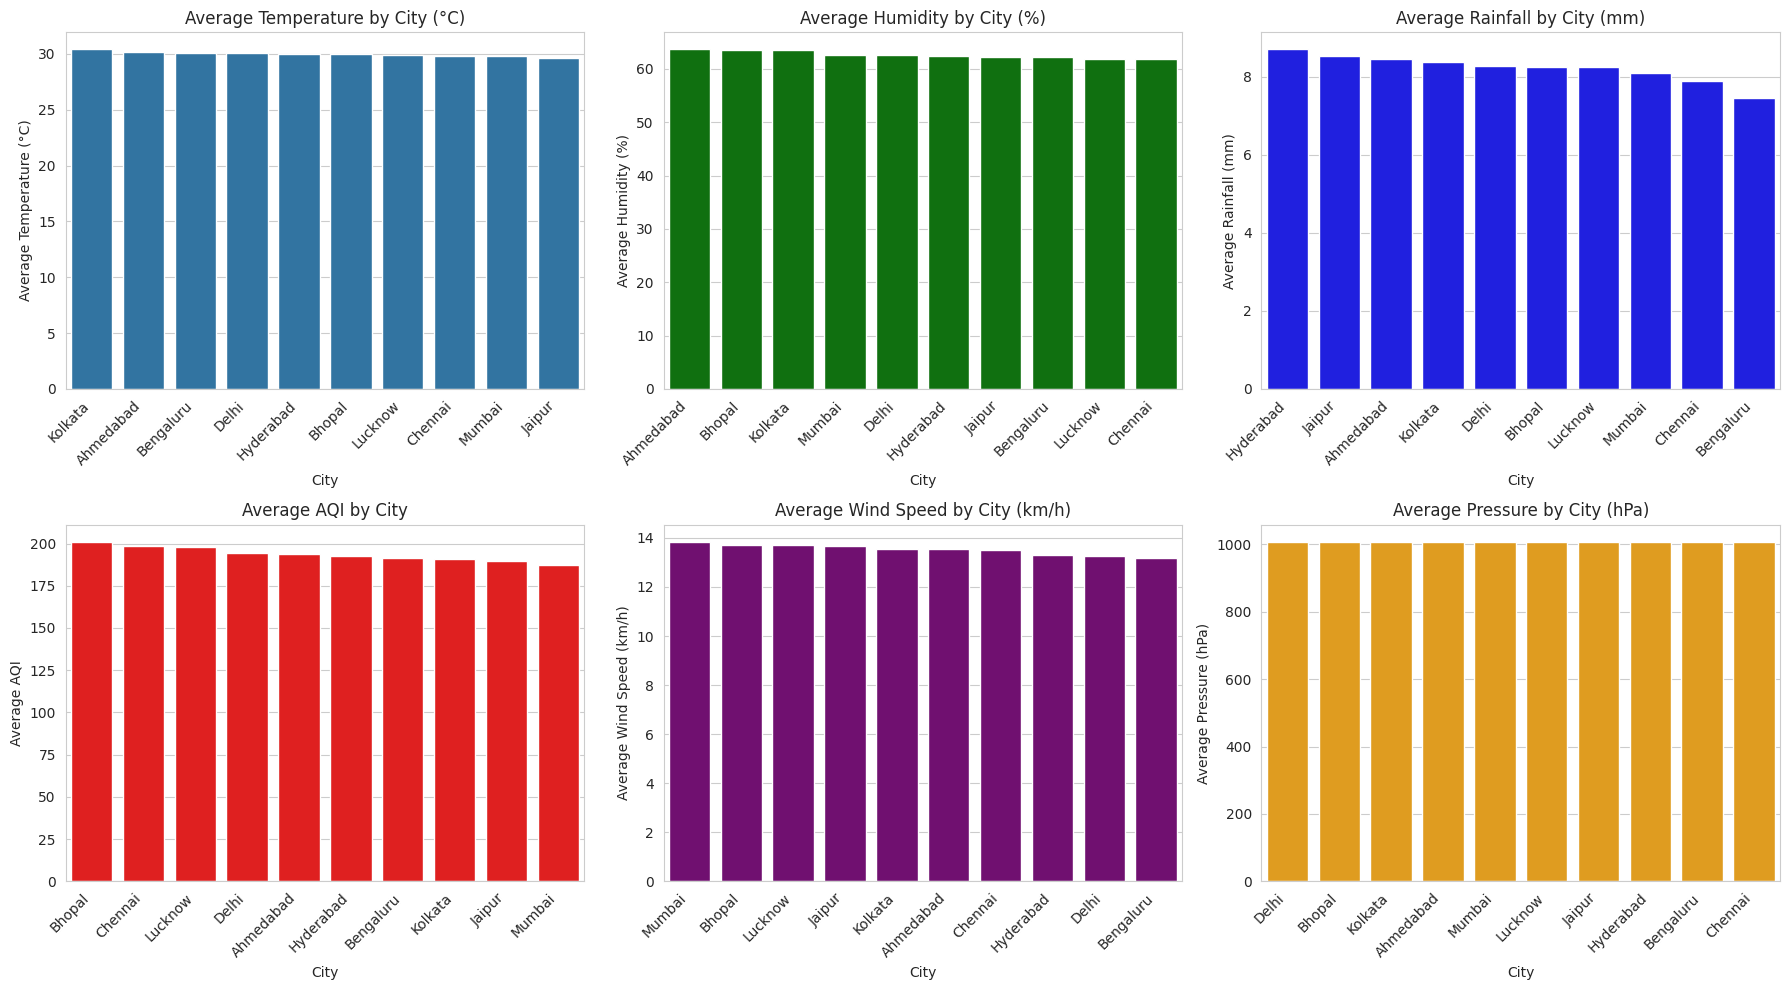

In [7]:
# City Comparison: Calculate average climate parameters for each city
city_avg_data = df.groupby('City').agg({
    'Temperature_Avg (°C)': 'mean',
    'Humidity (%)': 'mean',
    'Rainfall (mm)': 'mean',
    'AQI': 'mean',
    'Wind_Speed (km/h)': 'mean',
    'Pressure (hPa)': 'mean',
    'Cloud_Cover (%)': 'mean'
}).reset_index()

display(city_avg_data)

# Visualize city-wise comparison for key parameters
plt.figure(figsize=(18, 10))

# Average Temperature by City
plt.subplot(2, 3, 1)
sns.barplot(x='City', y='Temperature_Avg (°C)', data=city_avg_data.sort_values(by='Temperature_Avg (°C)', ascending=False))
plt.title('Average Temperature by City (°C)')
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45, ha='right')

# Average Humidity by City
plt.subplot(2, 3, 2)
sns.barplot(x='City', y='Humidity (%)', data=city_avg_data.sort_values(by='Humidity (%)', ascending=False), color='green')
plt.title('Average Humidity by City (%)')
plt.xlabel('City')
plt.ylabel('Average Humidity (%)')
plt.xticks(rotation=45, ha='right')

# Average Rainfall by City
plt.subplot(2, 3, 3)
sns.barplot(x='City', y='Rainfall (mm)', data=city_avg_data.sort_values(by='Rainfall (mm)', ascending=False), color='blue')
plt.title('Average Rainfall by City (mm)')
plt.xlabel('City')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45, ha='right')

# Average AQI by City
plt.subplot(2, 3, 4)
sns.barplot(x='City', y='AQI', data=city_avg_data.sort_values(by='AQI', ascending=False), color='red')
plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45, ha='right')

# Average Wind Speed by City
plt.subplot(2, 3, 5)
sns.barplot(x='City', y='Wind_Speed (km/h)', data=city_avg_data.sort_values(by='Wind_Speed (km/h)', ascending=False), color='purple')
plt.title('Average Wind Speed by City (km/h)')
plt.xlabel('City')
plt.ylabel('Average Wind Speed (km/h)')
plt.xticks(rotation=45, ha='right')

# Average Pressure by City
plt.subplot(2, 3, 6)
sns.barplot(x='City', y='Pressure (hPa)', data=city_avg_data.sort_values(by='Pressure (hPa)', ascending=False), color='orange')
plt.title('Average Pressure by City (hPa)')
plt.xlabel('City')
plt.ylabel('Average Pressure (hPa)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

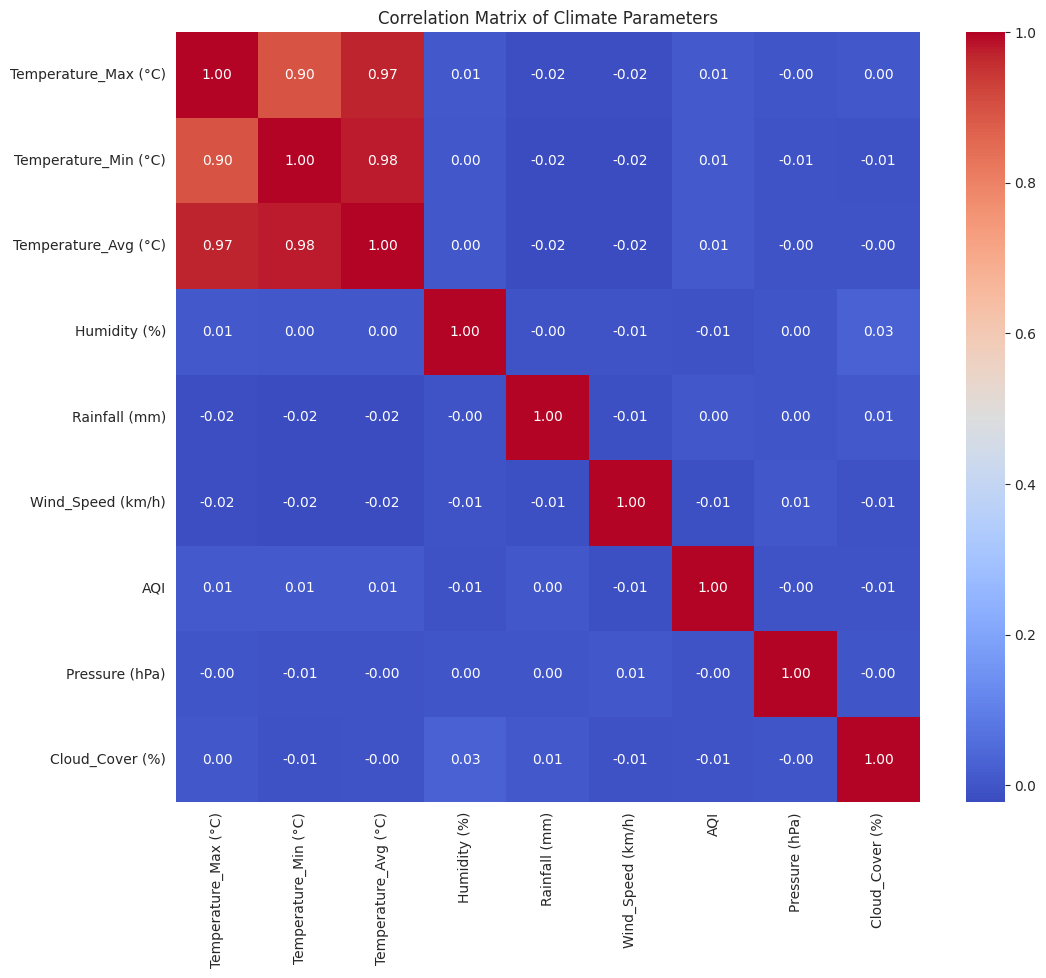

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Climate Parameters')
plt.show()

## Actionable Insights and Conclusion

### Trend Analysis Insights:
*   **Yearly Trends:** We observed slight variations in average temperature, humidity, and rainfall between 2024 and 2025. It is crucial to collect more years of data to identify clearer long-term climate change trends.
*   **Monthly Trends:** The monthly analysis clearly shows seasonal patterns. Temperatures are highest in summer months (March-May) and lowest in winter (December-February). Rainfall is typically concentrated during the monsoon season (June-September), and humidity levels generally follow rainfall patterns.

### City Comparison Insights:
*   **Temperature:** Kolkata recorded the highest average temperature, while Jaipur had the lowest. This highlights regional climatic differences, likely influenced by geographical location and urban heat island effects.
*   **Humidity:** Ahmedabad and Bhopal experienced the highest average humidity, which could be related to local water bodies or weather systems. Cities with high humidity might face challenges like increased discomfort and potential for mold growth.
*   **Rainfall:** Hyderabad and Ahmedabad received the most rainfall, suggesting that these cities are particularly susceptible to monsoon impacts. Bengaluru received the least rainfall.
*   **AQI (Air Quality Index):** Bhopal consistently showed the highest AQI, indicating poorer air quality compared to other cities. This demands immediate attention for environmental policy interventions.
*   **Wind Speed:** Mumbai had the highest average wind speed, which could help in dispersing pollutants but also indicates potential for higher impact during storms.
*   **Pressure:** Cities generally showed similar average pressure levels, indicating relatively uniform atmospheric conditions across the dataset, though slight variations exist.

### Correlation Analysis Insights:
*   **Temperature:** Maximum, minimum, and average temperatures are highly positively correlated with each other, as expected.
*   **Humidity and Rainfall:** A weak positive correlation exists between humidity and rainfall, suggesting that higher humidity often precedes or accompanies rainfall.
*   **AQI:** AQI showed weak correlations with most other climate parameters, suggesting that air quality might be influenced by factors not fully captured in this dataset (e.g., industrial emissions, traffic density, specific local pollutants).
*   **Wind Speed:** Wind speed has very little correlation with other parameters, indicating its independent variability.

### Overall Conclusion:
This dataset provides a foundational understanding of climate patterns across major Indian cities in 2024-2025. We identified clear seasonal variations and significant differences in climate parameters across cities. While the correlation analysis revealed expected relationships among temperature metrics and some weak ties between humidity and rainfall, AQI and wind speed largely operated independently of other climate parameters in this dataset.

### Actionable Recommendations:
1.  **For Cities with High AQI (e.g., Bhopal):** Implement targeted air quality improvement programs, including stricter emission controls for vehicles and industries, and promoting public transport and green infrastructure.
2.  **For Cities with High Rainfall (e.g., Hyderabad, Ahmedabad):** Develop and enhance urban drainage systems and implement water harvesting projects to manage excess water effectively and mitigate flood risks.
3.  **For Cities with Extreme Temperatures (e.g., Kolkata for heat, Jaipur for relative coolness):** Public health advisories for extreme weather events, and promote climate-resilient infrastructure (e.g., green roofs, cool pavements).
4.  **Long-term Monitoring:** Continue collecting granular climate data over extended periods to accurately model and predict climate change impacts and adjust urban planning accordingly.

This analysis serves as a valuable baseline for climate-related policy-making and urban planning strategies, aiming to enhance resilience and improve environmental quality in Indian cities.